# Reweighted $M_{\pi\pi}$ invariant mass
## Check that the CP-even and CP-odd reweighted MC matches data

### Turn off statistics box

In [1]:
gStyle->SetOptStat(0);

### Add BESIII style

In [2]:
gInterpreter->AddIncludePath("/data/lhcb/users/tat/KKpipi_Analysis_BESIII/include");

In [3]:
gROOT->ProcessLine(".L /data/lhcb/users/tat/KKpipi_Analysis_BESIII/src/Bes3plotstyle.cpp");

In [4]:
SetStyle();
SetPrelimStyle();

### Selection path

In [5]:
std::string SelectionPath("/data/bes3/tat/KKpipi_StrongPhase_Analysis_4Bins/Selection/");

### Load $KK$ tag

In [6]:
TChain KKChain("KKDoubleTag");
KKChain.Add((SelectionPath + "WithDeltaECuts/DoubleTag/KK/KKpipiDoubleTags_WithDeltaECuts_Data*.root").c_str());

### Load $\pi\pi\pi^0$ tag

In [7]:
TChain pipipi0Chain("pipipi0DoubleTag");
pipipi0Chain.Add((SelectionPath + "WithDeltaECuts/DoubleTag/pipipi0/KKpipiDoubleTags_WithDeltaECuts_Data*.root").c_str());

### Load $K_S\pi^0$ tag

In [8]:
TChain KSpi0Chain("KSpi0DoubleTag");
KSpi0Chain.Add((SelectionPath + "WithDeltaECuts/DoubleTag/KSpi0/KKpipiDoubleTags_WithDeltaECuts_Data*.root").c_str());

### Load $K_S\eta$ tag

In [9]:
TChain KSetaChain("KSetaDoubleTag");
KSetaChain.Add((SelectionPath + "WithDeltaECuts/DoubleTag/KSeta/KKpipiDoubleTags_WithDeltaECuts_Data*.root").c_str());

### Number of bins

In [10]:
int EvenBins = 8;
int OddBins = 6;

### Histogram range

In [11]:
double Min = 0.27914078*0.27914078;
double Max = 0.877486*0.877486;

### Histogram of $KK$ in signal region

In [12]:
TH1D KK_sig("KK_sig", "", EvenBins, Min, Max);
KKChain.Draw("SignalMpipi^2 >> KK_sig", "SignalMBC > 1.86 && SignalMBC < 1.87", "GOFF");

### Histogram of $KK$ in sideband region

In [13]:
TH1D KK_bkg("KK_bkg", "", EvenBins, Min, Max);
KKChain.Draw("SignalMpipi^2 >> KK_bkg", "SignalMBC > 1.845 && SignalMBC < 1.855", "GOFF");

### Histogram of $\pi\pi\pi^0$ in signal region

In [14]:
TH1D pipipi0_sig("pipipi0_sig", "", EvenBins, Min, Max);
pipipi0Chain.Draw("SignalMpipi^2 >> pipipi0_sig", "SignalMBC > 1.86 && SignalMBC < 1.87 && !(sqrt((TagPiPlusenergy+TagPiMinusenergy)^2-(TagPiPluspx+TagPiMinuspx)^2-(TagPiPluspy+TagPiMinuspy)^2-(TagPiPluspz+TagPiMinuspz)^2) > 0.479611 && sqrt((TagPiPlusenergy+TagPiMinusenergy)^2-(TagPiPluspx+TagPiMinuspx)^2-(TagPiPluspy+TagPiMinuspy)^2-(TagPiPluspz+TagPiMinuspz)^2) < 0.515611)", "GOFF");


### Histogram of $\pi\pi\pi^0$ in sideband region

In [15]:
TH1D pipipi0_bkg("pipipi0_bkg", "", EvenBins, Min, Max);
pipipi0Chain.Draw("SignalMpipi^2 >> pipipi0_bkg", "SignalMBC > 1.845 && SignalMBC < 1.855 && !(sqrt((TagPiPlusenergy+TagPiMinusenergy)^2-(TagPiPluspx+TagPiMinuspx)^2-(TagPiPluspy+TagPiMinuspy)^2-(TagPiPluspz+TagPiMinuspz)^2) > 0.479611 && sqrt((TagPiPlusenergy+TagPiMinusenergy)^2-(TagPiPluspx+TagPiMinuspx)^2-(TagPiPluspy+TagPiMinuspy)^2-(TagPiPluspz+TagPiMinuspz)^2) < 0.515611)", "GOFF");

### Histogram of $K_S\pi^0$ in signal region

In [16]:
TH1D KSpi0_sig("KSpi0_sig", "", OddBins, Min, Max);
KSpi0Chain.Draw("SignalMpipi^2 >> KSpi0_sig", "SignalMBC > 1.86 && SignalMBC < 1.87", "GOFF");

### Histogram of $K_S\pi^0$ in sideband region

In [17]:
TH1D KSpi0_bkg("KSpi0_bkg", "", OddBins, Min, Max);
KSpi0Chain.Draw("SignalMpipi^2 >> KSpi0_bkg", "SignalMBC > 1.845 && SignalMBC < 1.855", "GOFF");

### Histogram of $K_S\eta$ in signal region

In [18]:
TH1D KSeta_sig("KSeta_sig", "", OddBins, Min, Max);
KSetaChain.Draw("SignalMpipi^2 >> KSeta_sig", "SignalMBC > 1.86 && SignalMBC < 1.87", "GOFF");

### Histogram of $K_S\eta$ in sideband region

In [19]:
TH1D KSeta_bkg("KSeta_bkg", "", OddBins, Min, Max);
KSetaChain.Draw("SignalMpipi^2 >> KSeta_bkg", "SignalMBC > 1.845 && SignalMBC < 1.855", "GOFF");

### CP even histogram

In [20]:
TH1D CPEven_hist("CPEven_hist", "", EvenBins, Min, Max);
CPEven_hist.Add(&KK_sig);
CPEven_hist.Add(&KK_bkg, -1.0);
CPEven_hist.Add(&pipipi0_sig);
CPEven_hist.Add(&pipipi0_bkg, -1.0);
CPEven_hist.Scale(1.0/CPEven_hist.Integral());

### CP odd histogram

In [21]:
TH1D CPOdd_hist("CPOdd_hist", "", OddBins, Min, Max);
CPOdd_hist.Add(&KSpi0_sig);
CPOdd_hist.Add(&KSpi0_bkg, -1.0);
CPOdd_hist.Add(&KSeta_sig);
CPOdd_hist.Add(&KSeta_bkg, -1.0);
CPOdd_hist.Scale(1.0/CPOdd_hist.Integral());

### Load CP even MC

In [22]:
TChain EvenMCChain("KKDoubleTag");
EvenMCChain.Add((SelectionPath + "SignalMC/DoubleTag/KK/KKpipi_vs_KK_Binned_SignalMC_Reweighted.root").c_str());

### Load CP odd MC

In [23]:
TChain OddMCChain("KSpi0DoubleTag");
OddMCChain.Add((SelectionPath + "SignalMC/DoubleTag/KSpi0/KKpipi_vs_KSpi0_Binned_SignalMC_Reweighted.root").c_str());

### Get reweighted histograms

In [24]:
TH1D EvenMC_hist("EvenMC_hist", "", EvenBins, Min, Max);
EvenMCChain.Draw("SignalMpipi^2 >> EvenMC_hist", "ModelWeight_CPOdd", "GOFF NORM");

In [25]:
TH1D OddMC_hist("OddMC_hist", "", OddBins, Min, Max);
OddMCChain.Draw("SignalMpipi^2 >> OddMC_hist", "ModelWeight_CPEven", "GOFF NORM");

### Plot CP-even $m_{\pi\pi}$ distribution

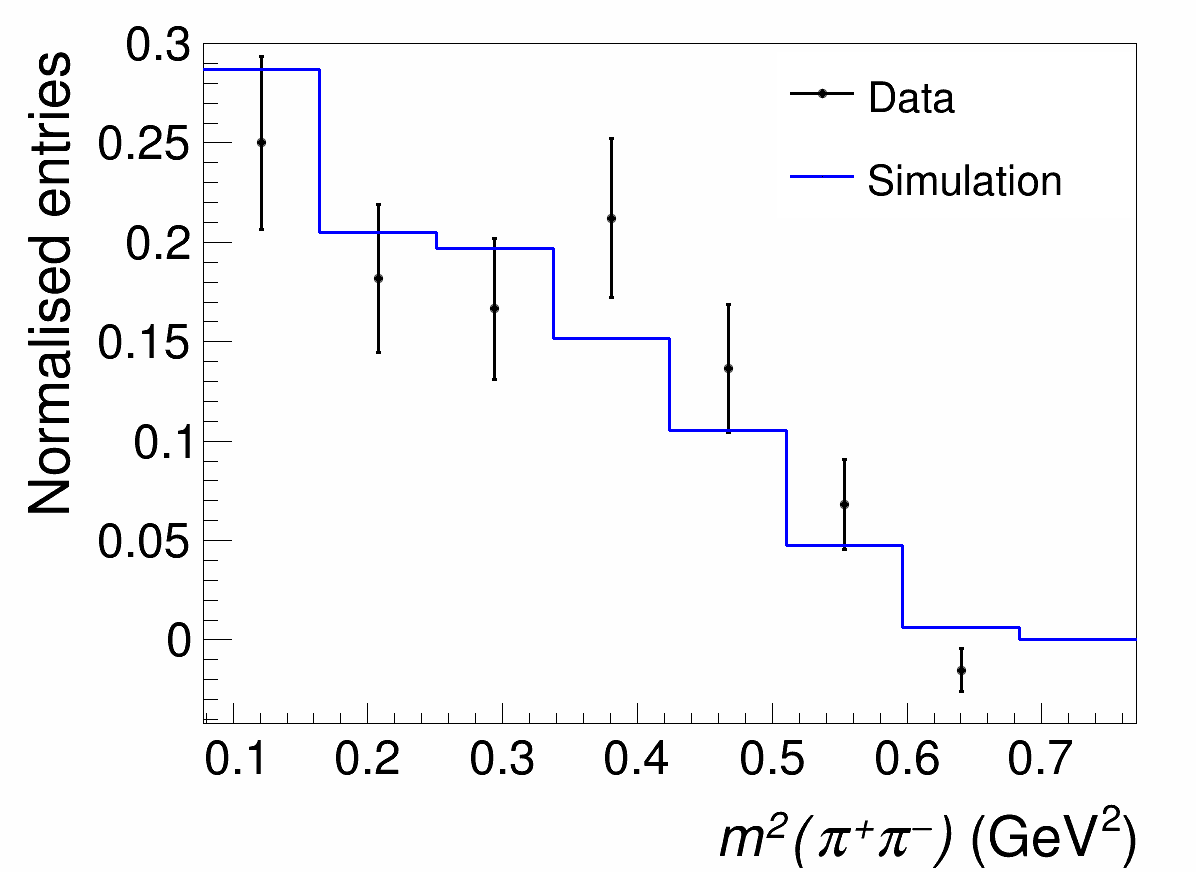

Info in <TCanvas::Print>: pdf file Mpipi_CPEven.pdf has been created


In [26]:
TCanvas c_even("c_even", "", 1200, 900);
CPEven_hist.Draw("P E1 NORM");
CPEven_hist.SetMarkerStyle(8);
CPEven_hist.SetTitle(";#it{m^{2}(#pi^{+}#pi^{#minus})} (GeV^{2});Normalised entries");
CPEven_hist.SetLineWidth(3);
CPEven_hist.SetLineColor(kBlack);
CPEven_hist.SetMaximum(0.3);
EvenMC_hist.Draw("HIST SAME");
EvenMC_hist.SetLineWidth(3);
EvenMC_hist.SetLineColor(kBlue);
TLegend Legend(0.65, 0.75, 0.95, 0.94);
Legend.AddEntry(&CPEven_hist, "Data");
Legend.AddEntry(&EvenMC_hist, "Simulation");
Legend.Draw("SAME");
c_even.Draw();
c_even.SaveAs("Mpipi_CPEven.pdf");

### Plot CP-odd $m_{\pi\pi}$ distribution

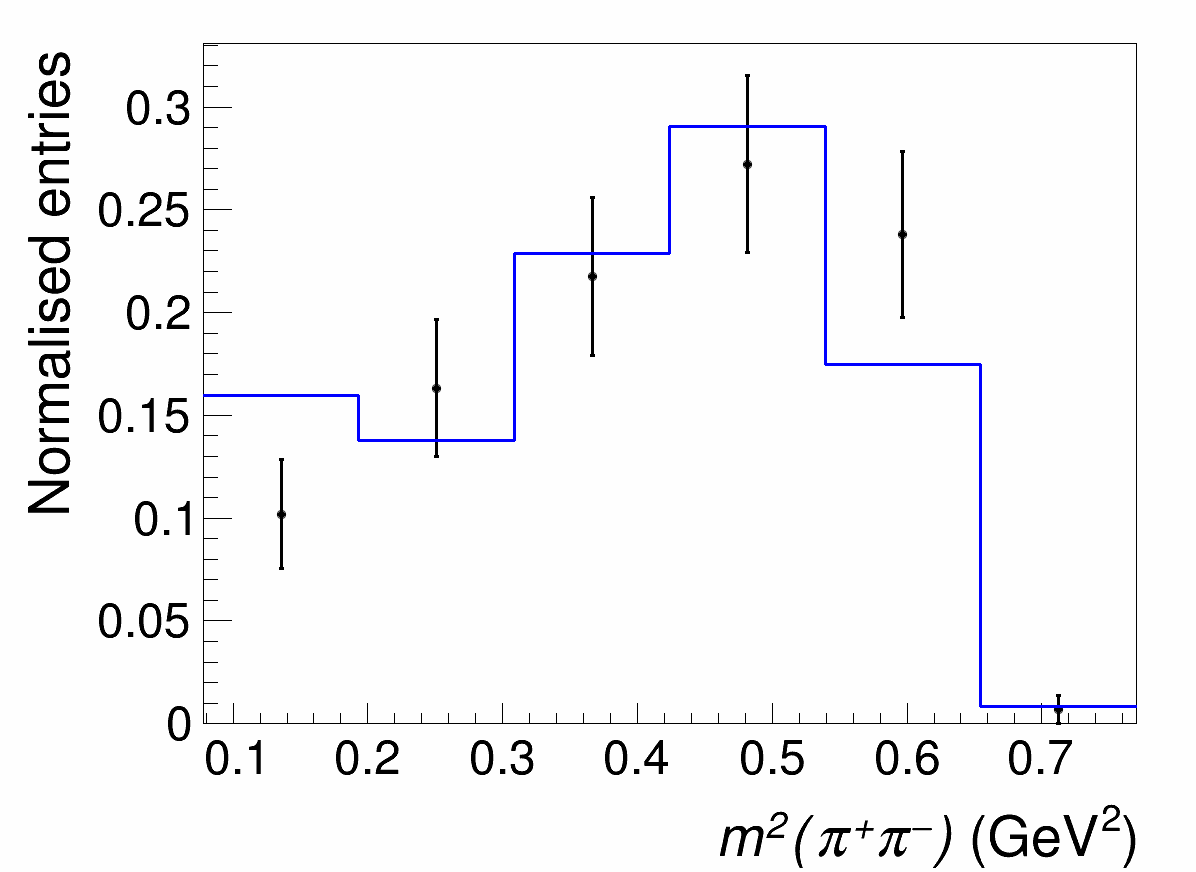

Info in <TCanvas::Print>: pdf file Mpipi_CPOdd.pdf has been created


In [27]:
TCanvas c_odd("c_odd", "", 1200, 900);
CPOdd_hist.Draw("P E1 NORM");
CPOdd_hist.SetMarkerStyle(8);
CPOdd_hist.SetTitle(";#it{m^{2}(#pi^{+}#pi^{#minus})} (GeV^{2});Normalised entries");
CPOdd_hist.SetLineWidth(3);
CPOdd_hist.SetLineColor(kBlack);
OddMC_hist.Draw("HIST SAME");
OddMC_hist.SetLineWidth(3);
OddMC_hist.SetLineColor(kBlue);
c_odd.Draw();
c_odd.SaveAs("Mpipi_CPOdd.pdf");